In [ ]:
# IMPORT LIBRARIES AND CHECK GPU

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional: avoid TensorFlow grabbing all GPU memory at once
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass


TensorFlow version: 2.20.0
GPU devices: []


In [ ]:
# CONFIGURATION

USE_FULL_DATASET = False   # True = all 50,000 train + 10,000 test images
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 10

if USE_FULL_DATASET:
    TRAIN_LIMIT = None
    TEST_LIMIT = None
else:
    TRAIN_LIMIT = 10000
    TEST_LIMIT = 2000

print("Configuration:")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Full dataset:", USE_FULL_DATASET)


Configuration:
Image size: 128
Batch size: 32
Epochs: 5
Full dataset: False


In [ ]:
# LOAD CIFAR-10 DATASET

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

if TRAIN_LIMIT is not None:
    x_train = x_train[:TRAIN_LIMIT]
    y_train = y_train[:TRAIN_LIMIT]

if TEST_LIMIT is not None:
    x_test = x_test[:TEST_LIMIT]
    y_test = y_test[:TEST_LIMIT]

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 826s 5us/step
Training images: (10000, 32, 32, 3)
Training labels: (10000,)
Testing images: (2000, 32, 32, 3)
Testing labels: (2000,)


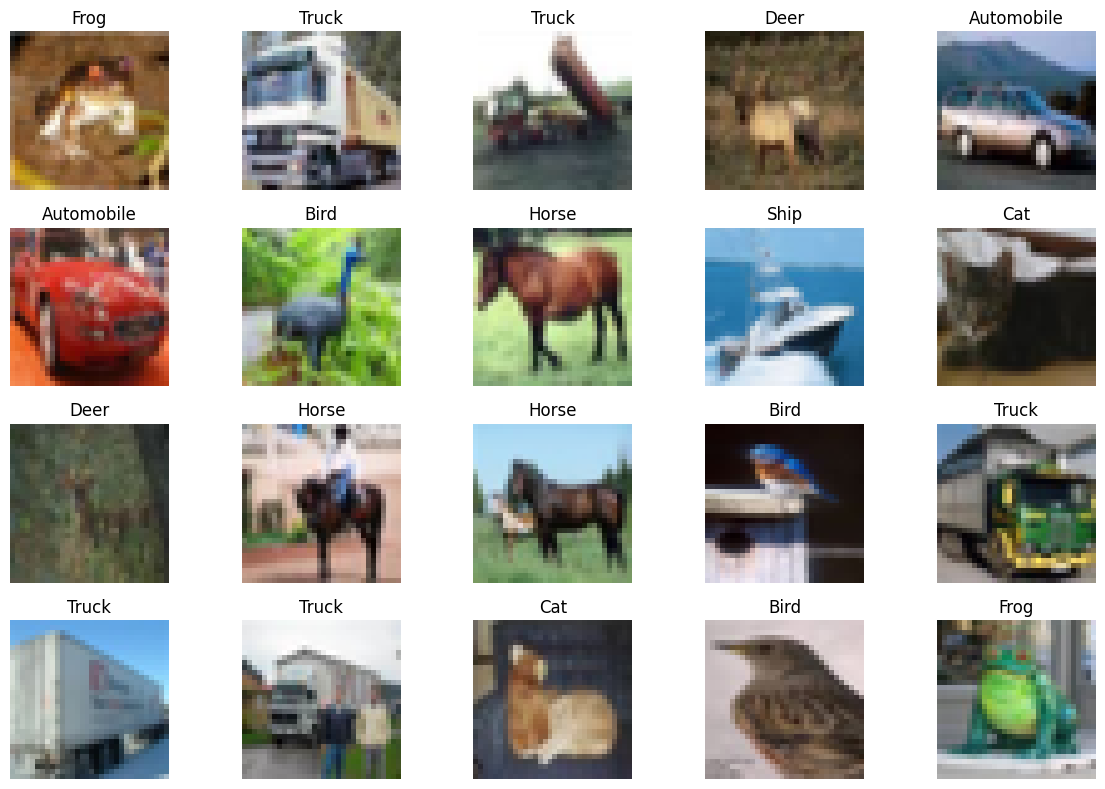

In [ ]:
# DISPLAY SAMPLE IMAGES

plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# CREATE TF.DATA INPUT PIPELINE

def resize_images(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

train_ds = (
    train_ds
    .shuffle(min(len(x_train), 10000), seed=SEED)
    .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pipeline created successfully.")


Dataset pipeline created successfully.


## 6. AlexNet

Keras does not include a standard ImageNet-pretrained AlexNet in `keras.applications`, so AlexNet is implemented manually for the comparison. Its classification layer is adapted to the 10 CIFAR-10 classes.


In [ ]:
# CREATE ALEXNET

def create_alexnet():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255.0),

        layers.Conv2D(96, kernel_size=11, strides=4, activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(256, kernel_size=5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Conv2D(384, kernel_size=3, padding="same", activation="relu"),
        layers.Conv2D(384, kernel_size=3, padding="same", activation="relu"),
        layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),

        layers.MaxPooling2D(pool_size=3, strides=2),

        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

alexnet = create_alexnet()
alexnet.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,407,306 (16.81 MB)

 Trainable params: 4,406,602 (16.81 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# ============================================================
# 7. TRAIN ALEXNET
# ============================================================

early_stopping_alexnet = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_alexnet = alexnet.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_alexnet],
    verbose=1
)

alexnet_time = time.time() - start

alexnet_loss, alexnet_accuracy = alexnet.evaluate(test_ds, verbose=0)

print(f"AlexNet test accuracy: {alexnet_accuracy:.4f}")
print(f"AlexNet test loss: {alexnet_loss:.4f}")
print(f"AlexNet training time: {alexnet_time/60:.2f} minutes")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.2179 - loss: 2.1025 - val_accuracy: 0.1275 - val_loss: 2.8318
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.2916 - loss: 1.8722 - val_accuracy: 0.3000 - val_loss: 1.8773
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.3518 - loss: 1.7460 - val_accuracy: 0.3230 - val_loss: 1.8649
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 488s 2s/step - accuracy: 0.3975 - loss: 1.6423 - val_accuracy: 0.4170 - val_loss: 1.6490
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.4346 - loss: 1.5682 - val_accuracy: 0.3625 - val_loss: 1.8100
AlexNet test accuracy: 0.4170
AlexNet test loss: 1.6490
AlexNet training time: 37.78 minutes


In [ ]:
# ============================================================
# 8. CREATE TRANSFER LEARNING MODEL
# ============================================================

def create_transfer_model(model_name):
    if model_name == "VGG16":
        base_model = VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess_input = tf.keras.applications.vgg16.preprocess_input

    elif model_name == "ResNet50":
        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess_input = tf.keras.applications.resnet50.preprocess_input

    elif model_name == "EfficientNetB0":
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
        preprocess_input = tf.keras.applications.efficientnet.preprocess_input

    else:
        raise ValueError("Supported models: VGG16, ResNet50, EfficientNetB0")

    # Freeze pretrained feature extractor
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [ ]:
# ============================================================
# 9. TRAIN VGG16
# ============================================================

vgg16 = create_transfer_model("VGG16")
vgg16.summary()

early_stopping_vgg = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_vgg16 = vgg16.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_vgg],
    verbose=1
)

vgg_time = time.time() - start

vgg_loss, vgg_accuracy = vgg16.evaluate(test_ds, verbose=0)

print(f"VGG16 test accuracy: {vgg_accuracy:.4f}")
print(f"VGG16 test loss: {vgg_loss:.4f}")
print(f"VGG16 training time: {vgg_time/60:.2f} minutes")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      2,570 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2393s 8s/step - accuracy: 0.6196 - loss: 1.4378 - val_accuracy: 0.7735 - val_loss: 0.6458
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2389s 8s/step - accuracy: 0.7695 - loss: 0.6947 - val_accuracy: 0.7980 - val_loss: 0.5719
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2331s 7s/step - accuracy: 0.8053 - loss: 0.5634 - val_accuracy: 0.8100 - val_loss: 0.5622
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2346s 7s/step - accuracy: 0.8373 - loss: 0.4700 - val_accuracy: 0.8080 - val_loss: 0.5689
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2415s 8s/step - accuracy: 0.8524 - loss: 0.4230 - val_accuracy: 0.8240 - val_loss: 0.5282
VGG16 test accuracy: 0.8240
VGG16 test loss: 0.5282
VGG16 training time: 197.89 minutes


In [ ]:
# ============================================================
# 10. TRAIN RESNET50
# ============================================================

resnet50 = create_transfer_model("ResNet50")
resnet50.summary()

early_stopping_resnet = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_resnet = resnet50.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_resnet],
    verbose=1
)

resnet_time = time.time() - start

resnet_loss, resnet_accuracy = resnet50.evaluate(test_ds, verbose=0)

print(f"ResNet50 test accuracy: {resnet_accuracy:.4f}")
print(f"ResNet50 test loss: {resnet_loss:.4f}")
print(f"ResNet50 training time: {resnet_time/60:.2f} minutes")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 128, 128,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 738s 2s/step - accuracy: 0.7573 - loss: 0.7617 - val_accuracy: 0.8400 - val_loss: 0.4641
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 739s 2s/step - accuracy: 0.8342 - loss: 0.4842 - val_accuracy: 0.8650 - val_loss: 0.3970
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 723s 2s/step - accuracy: 0.8607 - loss: 0.4052 - val_accuracy: 0.8670 - val_loss: 0.3706
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - accuracy: 0.8836 - loss: 0.3383 - val_accuracy: 0.8660 - val_loss: 0.3989
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 768s 2s/step - accuracy: 0.8958 - loss: 0.3102 - val_accuracy: 0.8705 - val_loss: 0.4006
ResNet50 test accuracy: 0.8670
ResNet50 test loss: 0.3706
ResNet50 training time: 61.10 minutes


In [ ]:
# ============================================================
# 11. TRAIN EFFICIENTNETB0
# ============================================================

efficientnet = create_transfer_model("EfficientNetB0")
efficientnet.summary()

early_stopping_eff = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_efficientnet = efficientnet.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping_eff],
    verbose=1
)

efficientnet_time = time.time() - start

efficientnet_loss, efficientnet_accuracy = efficientnet.evaluate(test_ds, verbose=0)

print(f"EfficientNetB0 test accuracy: {efficientnet_accuracy:.4f}")
print(f"EfficientNetB0 test loss: {efficientnet_loss:.4f}")
print(f"EfficientNetB0 training time: {efficientnet_time/60:.2f} minutes")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 274s 841ms/step - accuracy: 0.7977 - loss: 0.6241 - val_accuracy: 0.8665 - val_loss: 0.3744
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 833ms/step - accuracy: 0.8710 - loss: 0.3880 - val_accuracy: 0.8755 - val_loss: 0.3589
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 834ms/step - accuracy: 0.8919 - loss: 0.3217 - val_accuracy: 0.8875 - val_loss: 0.3341
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 299s 957ms/step - accuracy: 0.9095 - loss: 0.2706 - val_accuracy: 0.8820 - val_loss: 0.3452
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 300s 961ms/step - accuracy: 0.9169 - loss: 0.2419 - val_accuracy: 0.8920 - val_loss: 0.3287
EfficientNetB0 test accuracy: 0.8920
EfficientNetB0 test loss: 0.3287
EfficientNetB0 training time: 23.26 minutes


In [ ]:
# ============================================================
# 12. PERFORMANCE COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    "Model": [
        "AlexNet",
        "VGG16",
        "ResNet50",
        "EfficientNetB0"
    ],
    "Test Accuracy": [
        alexnet_accuracy,
        vgg_accuracy,
        resnet_accuracy,
        efficientnet_accuracy
    ],
    "Test Loss": [
        alexnet_loss,
        vgg_loss,
        resnet_loss,
        efficientnet_loss
    ],
    "Training Time (min)": [
        alexnet_time / 60,
        vgg_time / 60,
        resnet_time / 60,
        efficientnet_time / 60
    ],
    "Parameters": [
        alexnet.count_params(),
        vgg16.count_params(),
        resnet50.count_params(),
        efficientnet.count_params()
    ]
})

results = results.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(results)

# Save results to CSV
results.to_csv("transfer_learning_results.csv", index=False)
print("Results saved as transfer_learning_results.csv")


,Model,Test Accuracy,Test Loss,Training Time (min),Parameters
0,EfficientNetB0,0.892,0.328724,23.260103,4380077
1,ResNet50,0.867,0.370568,61.097314,24114826
2,VGG16,0.824,0.528155,197.894695,14848586
3,AlexNet,0.417,1.649013,37.775874,4407306


Results saved as transfer_learning_results.csv


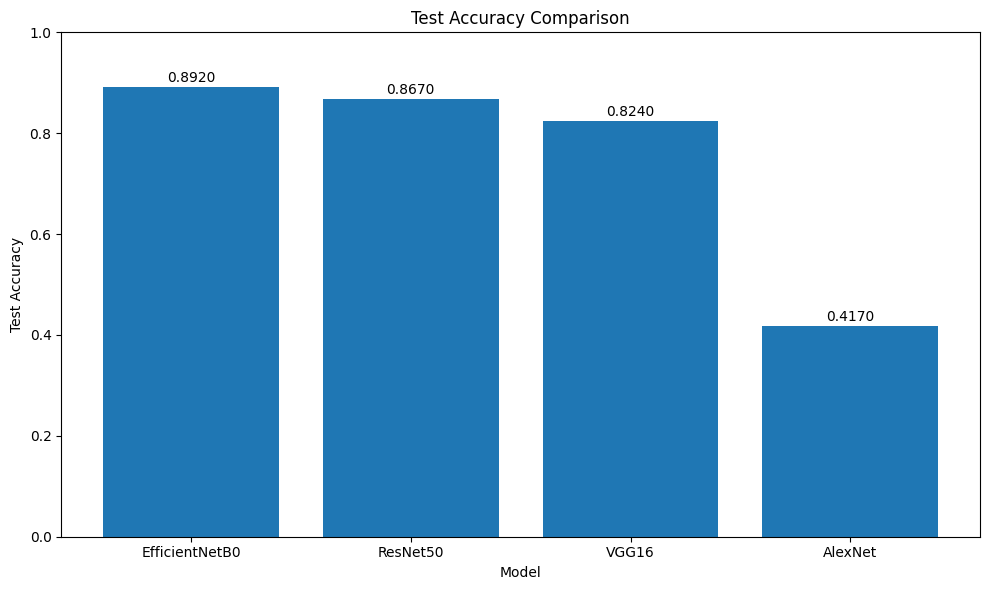

In [ ]:
# ============================================================
# 13. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.ylim(0, 1)

for bar, value in zip(bars, results["Test Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


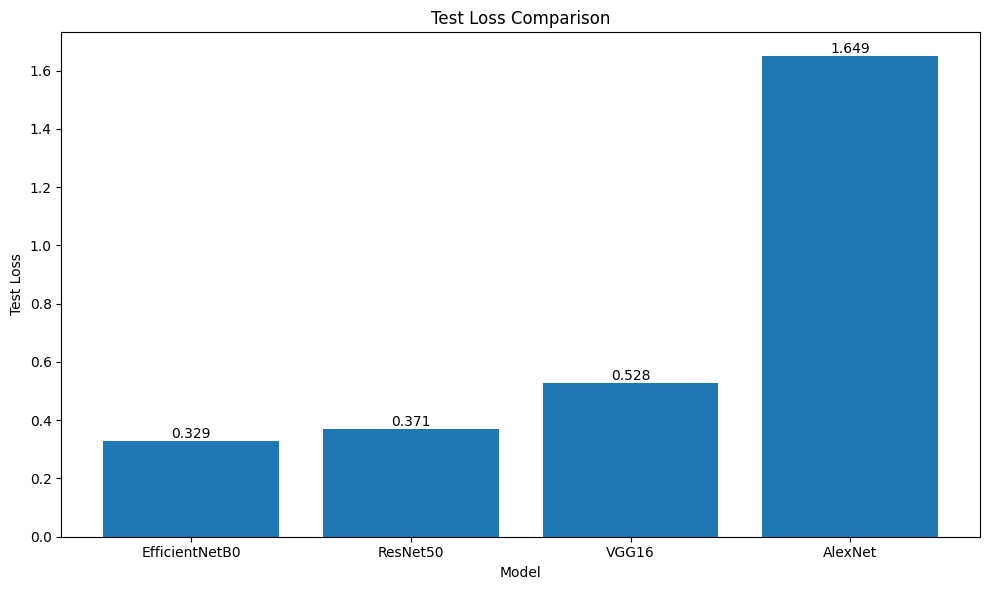

In [ ]:
# ============================================================
# 14. TEST LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["Test Loss"]
)

plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")

for bar, value in zip(bars, results["Test Loss"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


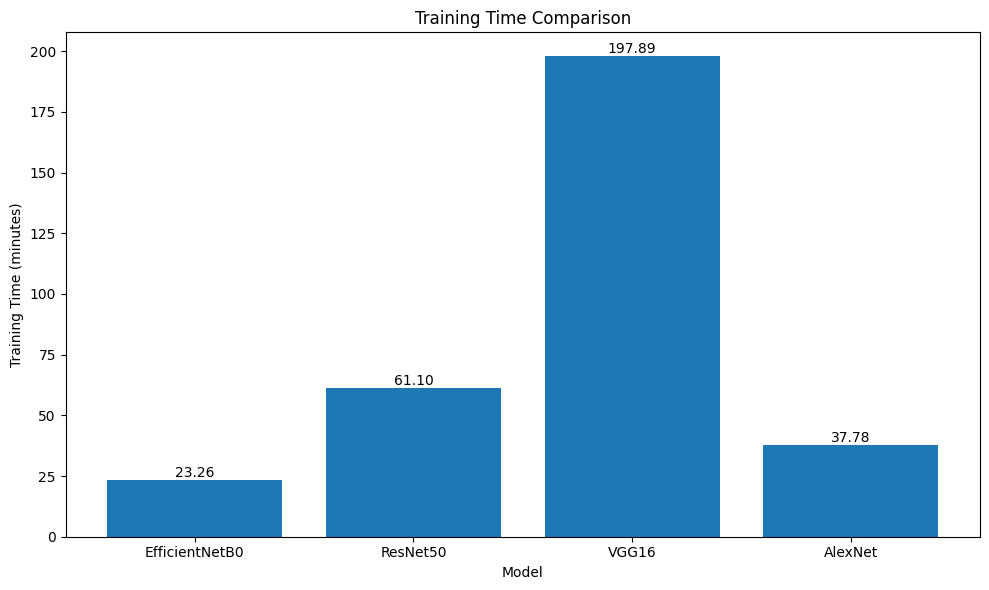

In [ ]:
# ============================================================
# 15. TRAINING TIME COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["Training Time (min)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")

for bar, value in zip(bars, results["Training Time (min)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


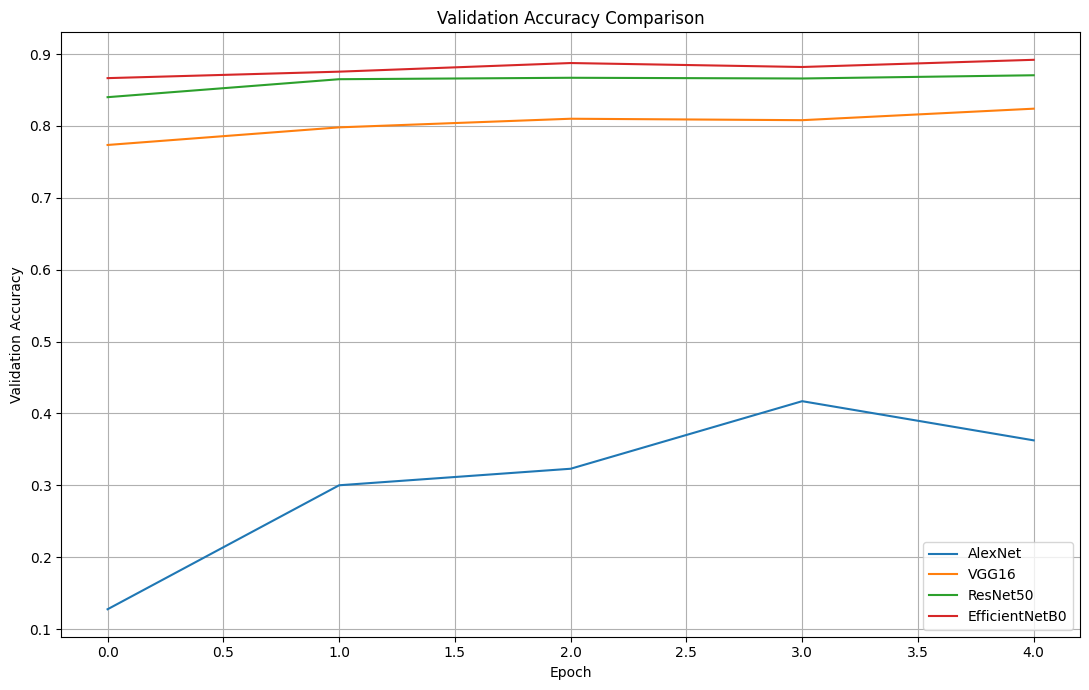

In [ ]:
# ============================================================
# 16. VALIDATION ACCURACY CURVES
# ============================================================

plt.figure(figsize=(11, 7))

plt.plot(history_alexnet.history["val_accuracy"], label="AlexNet")
plt.plot(history_vgg16.history["val_accuracy"], label="VGG16")
plt.plot(history_resnet.history["val_accuracy"], label="ResNet50")
plt.plot(history_efficientnet.history["val_accuracy"], label="EfficientNetB0")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


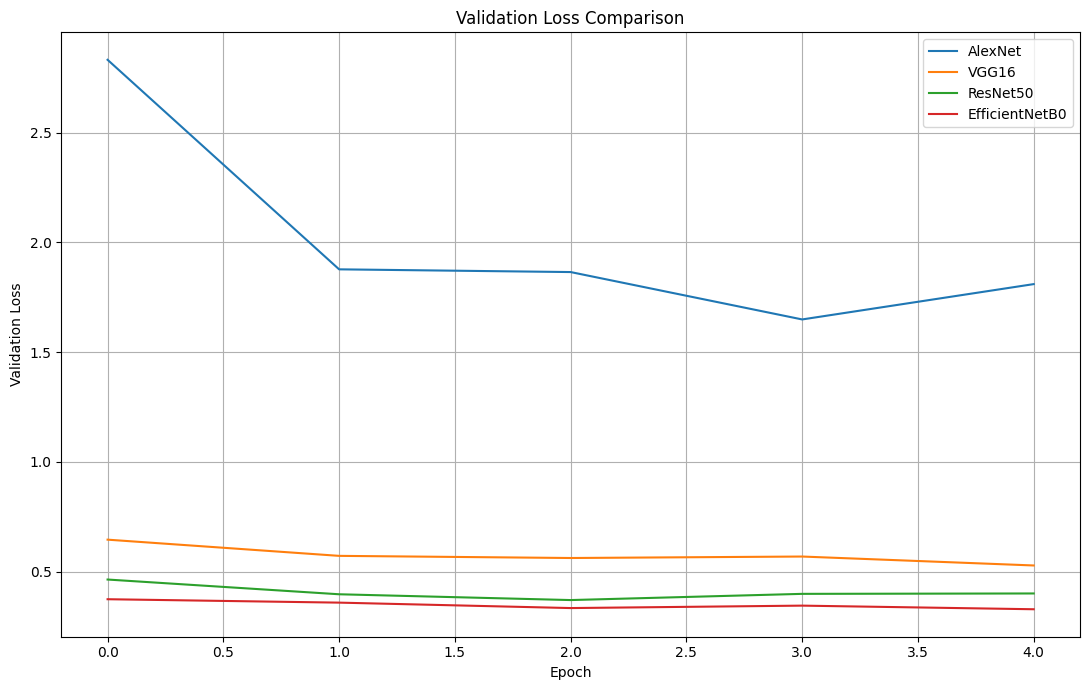

In [ ]:
# ============================================================
# 17. VALIDATION LOSS CURVES
# ============================================================

plt.figure(figsize=(11, 7))

plt.plot(history_alexnet.history["val_loss"], label="AlexNet")
plt.plot(history_vgg16.history["val_loss"], label="VGG16")
plt.plot(history_resnet.history["val_loss"], label="ResNet50")
plt.plot(history_efficientnet.history["val_loss"], label="EfficientNetB0")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 18. Prediction on a Test Image

The following cell uses the EfficientNetB0 transfer-learning model to classify one CIFAR-10 test image.


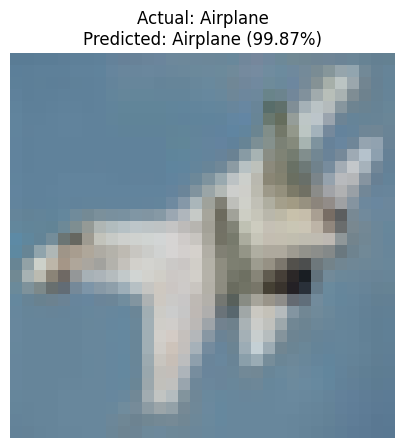

Actual class: Airplane
Predicted class: Airplane
Confidence: 99.87%


In [ ]:
# ============================================================
# 18. SINGLE IMAGE PREDICTION
# ============================================================

index = 10

original_image = x_test[index]
actual_label = y_test[index]

image_resized = tf.image.resize(
    original_image,
    (IMG_SIZE, IMG_SIZE)
)

image_batch = tf.expand_dims(image_resized, axis=0)

prediction = efficientnet.predict(image_batch, verbose=0)

predicted_label = int(np.argmax(prediction[0]))
confidence = float(np.max(prediction[0]))

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"Predicted: {class_names[predicted_label]} "
    f"({confidence * 100:.2f}%)"
)
plt.axis("off")
plt.show()

print("Actual class:", class_names[actual_label])
print("Predicted class:", class_names[predicted_label])
print(f"Confidence: {confidence * 100:.2f}%")
